In [2]:
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pooch
import scanpy as sc

In [3]:
datapath = pooch.retrieve(
    path=pooch.os_cache("scverse_tutorials"),
    url="https://exampledata.scverse.org/tutorials/scverse-getting-started-anndata-pbmc3k_processed.h5ad",
    known_hash="md5:b80deb0997f96b45d06f19c694e46243",
)

In [4]:
adata = anndata.read_h5ad(datapath)
adata

AnnData object with n_obs × n_vars = 2638 × 11505
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw'
    obsp: 'distances_all'

In [5]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2076576 stored elements and shape (2638, 11505)>

In [6]:
# look at the non-zero values in the data
print(adata.X.data)
# look at their indices / positions in the data matrix
print(adata.X.indices)
# compute the fraction of non-zero entries
print(adata.X.nnz / np.prod(adata.X.shape))

[0.6496621 0.6496621 1.0402015 ... 0.7506172 0.7506172 1.4713064]
[   19    52    58 ... 11498 11501 11504]
0.068420527186156


In [7]:
adata.layers

Layers with keys: raw

In [8]:
adata.layers["raw"]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2076576 stored elements and shape (2638, 11505)>

In [9]:
adata.layers["raw"].data

array([1, 1, 2, ..., 1, 1, 3], shape=(2076576,))

In [10]:
# copy raw counts to new layer
adata.layers["counts_per_million"] = adata.layers["raw"].copy()

# normalize the new layer
sc.pp.normalize_total(adata, target_sum=10**6, layer="counts_per_million")
print(adata.layers)

Layers with keys: raw, counts_per_million


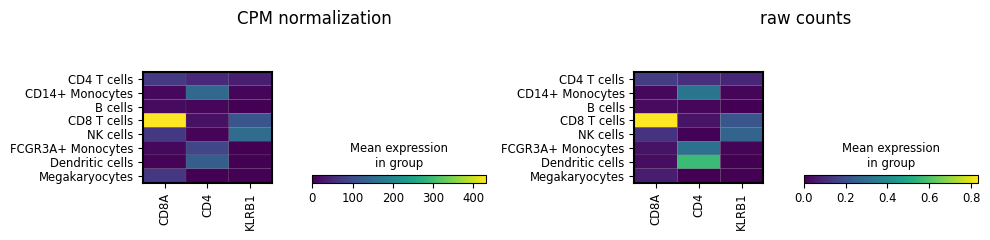

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))
genes_of_interest = ["CD8A", "CD4", "KLRB1"]
sc.pl.matrixplot(
    adata,
    groupby="louvain_cell_types",
    var_names=genes_of_interest,
    layer="counts_per_million", 
    ax = ax1,
    show=False,
)
ax1.set_title("CPM normalization")

sc.pl.matrixplot(
    adata, 
    groupby="louvain_cell_types",
    var_names=genes_of_interest,
    layer="raw",
    ax=ax2,
    show=False,
)
ax2.set_title("raw counts")
plt.tight_layout()

In [12]:
adata.obs

,n_genes,percent_mito,n_counts,louvain_cell_types
cell_barcode,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells
...,...,...,...,...
TTTCGAACTCTCAT-1,1155,0.021104,3459.0,CD14+ Monocytes
TTTCTACTGAGGCA-1,1227,0.009294,3443.0,B cells
TTTCTACTTCCTCG-1,622,0.021971,1684.0,B cells


In [13]:
adata.obs.keys()

Index(['n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types'], dtype='object')

In [14]:
adata.obs["louvain_cell_types"]

cell_barcode
AAACATACAACCAC-1        CD4 T cells
AAACATTGAGCTAC-1            B cells
AAACATTGATCAGC-1        CD4 T cells
AAACCGTGCTTCCG-1    CD14+ Monocytes
AAACCGTGTATGCG-1           NK cells
                         ...       
TTTCGAACTCTCAT-1    CD14+ Monocytes
TTTCTACTGAGGCA-1            B cells
TTTCTACTTCCTCG-1            B cells
TTTGCATGAGAGGC-1            B cells
TTTGCATGCCTCAC-1        CD4 T cells
Name: louvain_cell_types, Length: 2638, dtype: category
Categories (8, object): ['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'CD8 T cells', 'NK cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']

In [15]:
print(sum(adata.obs["louvain_cell_types"]== "B cells"))

342


In [16]:
adata.obs["is_low_quality"] = adata.obs["percent_mito"] > 0.03
adata.obs

,n_genes,percent_mito,n_counts,louvain_cell_types,is_low_quality
cell_barcode,,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells,True
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells,True
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells,False
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes,False
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells,False
...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,0.021104,3459.0,CD14+ Monocytes,False
TTTCTACTGAGGCA-1,1227,0.009294,3443.0,B cells,False
TTTCTACTTCCTCG-1,622,0.021971,1684.0,B cells,False


In [17]:
print(sum((adata.obs["is_low_quality"] == True) & (adata.obs["louvain_cell_types"]== "B cells")))

48


In [18]:
adata.var

,gene_names,n_cells,gene_ids
gene_names,,,
LINC00115,LINC00115,18,ENSG00000225880
NOC2L,NOC2L,258,ENSG00000188976
KLHL17,KLHL17,9,ENSG00000187961
PLEKHN1,PLEKHN1,7,ENSG00000187583
HES4,HES4,145,ENSG00000188290
...,...,...,...
MT-ND4L,MT-ND4L,398,ENSG00000212907
MT-ND4,MT-ND4,2588,ENSG00000198886
MT-ND5,MT-ND5,1399,ENSG00000198786


In [19]:
adata.obs_names

Index(['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1',
       'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1', 'AAACGCACTGGTAC-1',
       'AAACGCTGACCAGT-1', 'AAACGCTGGTTCTT-1', 'AAACGCTGTAGCCA-1',
       'AAACGCTGTTTCTG-1',
       ...
       'TTTCAGTGTCACGA-1', 'TTTCAGTGTCTATC-1', 'TTTCAGTGTGCAGT-1',
       'TTTCCAGAGGTGAG-1', 'TTTCGAACACCTGA-1', 'TTTCGAACTCTCAT-1',
       'TTTCTACTGAGGCA-1', 'TTTCTACTTCCTCG-1', 'TTTGCATGAGAGGC-1',
       'TTTGCATGCCTCAC-1'],
      dtype='object', name='cell_barcode', length=2638)

In [20]:
adata.var_names

Index(['LINC00115', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4', 'ISG15', 'AGRN',
       'C1orf159', 'TNFRSF18', 'TNFRSF4',
       ...
       'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', name='gene_names', length=11505)

In [21]:
adata.var_names = adata.var["gene_ids"]

In [22]:
adata.var_names

Index(['ENSG00000225880', 'ENSG00000188976', 'ENSG00000187961',
       'ENSG00000187583', 'ENSG00000188290', 'ENSG00000187608',
       'ENSG00000188157', 'ENSG00000131591', 'ENSG00000186891',
       'ENSG00000186827',
       ...
       'ENSG00000198712', 'ENSG00000228253', 'ENSG00000198899',
       'ENSG00000198938', 'ENSG00000198840', 'ENSG00000212907',
       'ENSG00000198886', 'ENSG00000198786', 'ENSG00000198695',
       'ENSG00000198727'],
      dtype='object', name='gene_ids', length=11505)

In [23]:
adata.var_names = adata.var["gene_names"]
adata.var

,gene_names,n_cells,gene_ids
gene_names,,,
LINC00115,LINC00115,18,ENSG00000225880
NOC2L,NOC2L,258,ENSG00000188976
KLHL17,KLHL17,9,ENSG00000187961
PLEKHN1,PLEKHN1,7,ENSG00000187583
HES4,HES4,145,ENSG00000188290
...,...,...,...
MT-ND4L,MT-ND4L,398,ENSG00000212907
MT-ND4,MT-ND4,2588,ENSG00000198886
MT-ND5,MT-ND5,1399,ENSG00000198786


In [24]:
adata_small = adata[:5, ["LYZ", "FOS", "MALAT1"]]
adata_small.shape

(5, 3)

In [25]:
adata_small.X.toarray()

array([[0.6496621 , 2.4036813 , 3.8249342 ],
       [0.8553989 , 0.64266497, 4.174533  ],
       [0.878057  , 2.8014445 , 4.7918878 ],
       [3.0494576 , 1.6464083 , 2.3237872 ],
       [0.        , 0.        , 3.923651  ]], dtype=float32)

In [26]:
adata_small.obs

,n_genes,percent_mito,n_counts,louvain_cell_types,is_low_quality
cell_barcode,,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells,True
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells,True
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells,False
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes,False
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells,False


In [27]:
adata_small.var 

,gene_names,n_cells,gene_ids
gene_names,,,
LYZ,LYZ,1631,ENSG00000090382
FOS,FOS,2473,ENSG00000170345
MALAT1,MALAT1,2699,ENSG00000251562


In [28]:
adata_high_quality = adata[~adata.obs["is_low_quality"], :]

In [29]:
adata_high_quality.obs

,n_genes,percent_mito,n_counts,louvain_cell_types,is_low_quality
cell_barcode,,,,,
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells,False
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes,False
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells,False
AAACGCACTGGTAC-1,782,0.016644,2163.0,CD8 T cells,False
AAACGCTGTAGCCA-1,533,0.011765,1275.0,CD4 T cells,False
...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,0.021104,3459.0,CD14+ Monocytes,False
TTTCTACTGAGGCA-1,1227,0.009294,3443.0,B cells,False
TTTCTACTTCCTCG-1,622,0.021971,1684.0,B cells,False


In [30]:
adata.uns.keys()

dict_keys(['louvain', 'louvain_colors', 'pca'])

In [31]:
adata.obsm

AxisArrays with keys: X_pca, X_tsne, X_umap

In [32]:
for key in adata.obsm:
    print(key, adata.obsm[key].shape, sep="\t")

X_pca	(2638, 50)
X_tsne	(2638, 2)
X_umap	(2638, 2)


C:\Users\Davi\AppData\Local\Temp\ipykernel_676\1837462343.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


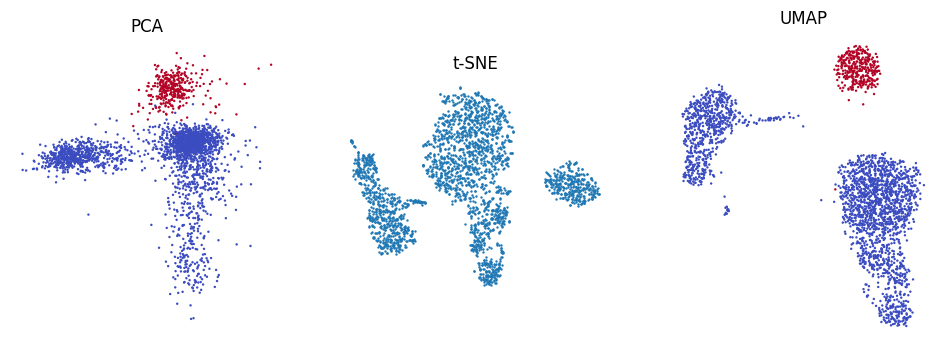

In [33]:
plt.figure(figsize=(12, 4))

# PCA

plt.subplot(1, 3, 1)
plt.scatter(
    x=adata.obsm["X_pca"][:, 0], # PCA dim 1
    y=adata.obsm["X_pca"][:, 1], # PCA dim 2
    c=adata.obs["louvain_cell_types"] == "B cells",
    s=3,
    linewidths= 0,
    cmap = "coolwarm",
)

plt.title("PCA")
plt.axis("off")
plt.gca().set_aspect("equal")

# t-SNE 

plt.subplot(1, 3, 2)
plt.scatter(
    x=adata.obsm["X_tsne"][:, 0],
    y=adata.obsm["X_tsne"][:, 1],
    s=3,
    linewidths=0,
    cmap="coolwarm",
)

plt.title("t-SNE")
plt.axis("off")
plt.gca().set_aspect("equal")

# UMAP
plt.subplot(1, 3, 3)
plt.scatter(
    x=adata.obsm["X_umap"][:, 0],
    y=adata.obsm["X_umap"][:, 1],
    c=adata.obs["louvain_cell_types"] == "B cells",
    s=3,
    linewidths=0,
    cmap= "coolwarm",

)

plt.title("UMAP")
plt.axis("off")
plt.gca().set_aspect("equal")

In [34]:
adata.obsp

PairwiseArrays with keys: distances_all

In [35]:
adata.obsp["distances_all"]

array([[ 0.        , 18.98223389, 15.39625646, ..., 17.44791227,
        19.66225537, 13.4530516 ],
       [18.98223389,  0.        , 21.37320952, ..., 17.39917931,
        16.59099551, 20.29010799],
       [15.39625646, 21.37320952,  0.        , ..., 17.48199881,
        19.54703132, 13.22466662],
       ...,
       [17.44791227, 17.39917931, 17.48199881, ...,  0.        ,
        14.53959947, 14.15720293],
       [19.66225537, 16.59099551, 19.54703132, ..., 14.53959947,
         0.        , 16.96518854],
       [13.4530516 , 20.29010799, 13.22466662, ..., 14.15720293,
        16.96518854,  0.        ]], shape=(2638, 2638))

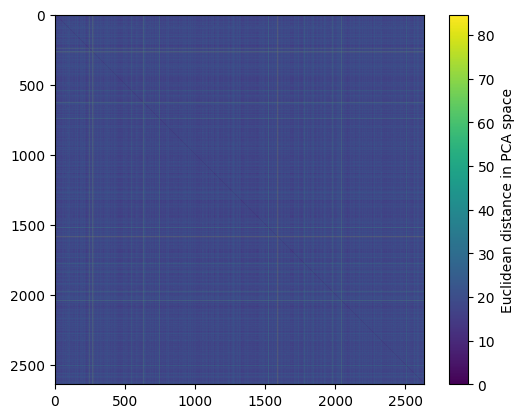

In [36]:
plt.imshow(adata.obsp["distances_all"])
plt.colorbar(label="Euclidean distance in PCA space")
plt.show()

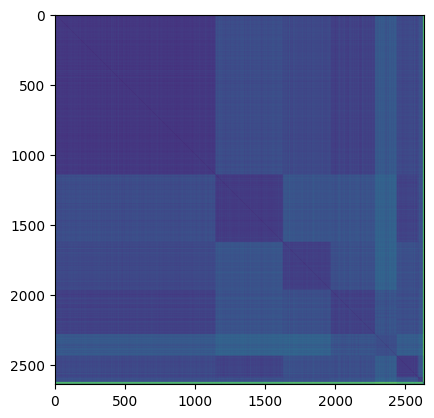

In [37]:
reorder_by_celltype = np.argsort(adata.obs["louvain_cell_types"])
plt.imshow(adata[reorder_by_celltype,:].obsp["distances_all"])
plt.show()

In [38]:
adata.uns.keys()

dict_keys(['louvain', 'louvain_colors', 'pca'])

In [39]:
# louvain clustering parameters
print(adata.uns["louvain"])

{'params': {'random_state': array([0]), 'resolution': array([1])}}


In [40]:
# louvain clustering plotting colors
print(adata.uns["louvain_colors"])

['#1f77b4' '#ff7f0e' '#2ca02c' '#d62728' '#9467bd' '#8c564b' '#e377c2'
 '#bcbd22']


In [41]:
# PCA: variance explained
print(adata.uns["pca"])

{'variance': array([32.11044  , 18.718647 , 15.607319 , 13.235274 ,  4.8012376,
        3.977329 ,  3.5053132,  3.1576602,  3.028463 ,  2.9777625,
        2.8842385,  2.8583548,  2.849085 ,  2.8220255,  2.811057 ,
        2.781576 ,  2.7436602,  2.7404478,  2.736062 ,  2.6872916,
        2.671316 ,  2.6690092,  2.6442325,  2.6394093,  2.6157827,
        2.6102393,  2.575101 ,  2.5691617,  2.563295 ,  2.5489197,
        2.5080354,  2.4762378,  2.264355 ,  2.1844513,  2.1353922,
        2.096509 ,  2.0606086,  2.0105643,  1.9703175,  1.9465197,
        1.9220033,  1.8847997,  1.8349565,  1.8038161,  1.7930729,
        1.7611799,  1.7322571,  1.721284 ,  1.6937429,  1.6519767],
      dtype=float32), 'variance_ratio': array([0.02012818, 0.01173364, 0.00978333, 0.00829643, 0.00300962,
       0.00249316, 0.00219728, 0.00197936, 0.00189837, 0.00186659,
       0.00180796, 0.00179174, 0.00178593, 0.00176896, 0.00176209,
       0.00174361, 0.00171984, 0.00171783, 0.00171508, 0.00168451,
       0

In [42]:
adata.X[:5, 5:10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.64266497, 0.        ],
       [0.532456  , 0.        , 0.        , 0.        , 0.        ],
       [2.1446393 , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]],
      dtype=float32)

In [43]:
adata_view = adata[:5, 5:10]
adata_view

View of AnnData object with n_obs × n_vars = 5 × 5
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types', 'is_low_quality'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw', 'counts_per_million'
    obsp: 'distances_all'

In [ ]:
adata_view.X.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.64266497, 0.        ],
       [0.532456  , 0.        , 0.        , 0.        , 0.        ],
       [2.1446393 , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]],
      dtype=float32)

In [45]:
adata.X[0, 7] = 99
adata_view.X.toarray()

c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


array([[ 0.        ,  0.        , 99.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.64266497,  0.        ],
       [ 0.532456  ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 2.1446393 ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]],
      dtype=float32)

In [46]:
adata_view  # still a view

View of AnnData object with n_obs × n_vars = 5 × 5
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types', 'is_low_quality'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw', 'counts_per_million'
    obsp: 'distances_all'

In [47]:
adata_view_copy = adata_view.copy()
adata_view_copy  # an actual AnnData object!

AnnData object with n_obs × n_vars = 5 × 5
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types', 'is_low_quality'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw', 'counts_per_million'
    obsp: 'distances_all'

In [48]:
adata_view.obs["new_column"] = "Test"  # add a new column to the `obs` dataframe
adata_view  # Not a view anymore!

C:\Users\Davi\AppData\Local\Temp\ipykernel_676\3524272241.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_view.obs["new_column"] = "Test"  # add a new column to the `obs` dataframe


AnnData object with n_obs × n_vars = 5 × 5
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types', 'is_low_quality', 'new_column'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw', 'counts_per_million'
    obsp: 'distances_all'

In [49]:
adata.X[0, 8] = 98
adata.X[:5, 5:10].toarray()  # the parent of course has the change

c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


array([[ 0.        ,  0.        , 99.        , 98.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.64266497,  0.        ],
       [ 0.532456  ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 2.1446393 ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]],
      dtype=float32)